# Welfare Bot - Clustering Analysis

Tässä notebookissa käytän klusterointia käyttäjien hyvinvointiprofiilien analysointiin.
Tavoitteena on löytää datasta erilaisia käyttäjäryhmiä ilman valmiita riskiluokkia.
Klusterointi kuuluu ohjaamattoman oppimisen (unsupervised learning) menetelmiin.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("../data/welfare_bot_metrics_cleaned.csv")

data = data.dropna()

data.head()

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.89,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.98,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.67,low
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.25,low
5,2025-01-06,Aino Mäkinen,aino.makinen@demo.fi,3.97,4.75,2.80,0.72,0.97,2.90,8.56,low


## Feature selection

Valitsen hyvinvointimittarit, joiden perusteella klusterointimalli yrittää löytää käyttäjäryhmiä.
Tavoitteena ei ole ennustaa riskitasoa, vaan löytää datasta luonnollisia hyvinvointiprofiileja.

In [3]:
features = [
    "mood_score",
    "sleep_score",
    "food_score",
    "hydration_score",
    "medication_score",
    "social_score",
    "overall_score"
]

X = data[features]

## Data scaling

Klusterointimallit toimivat paremmin, kun kaikki featuret ovat samalla skaalalla.
Tässä vaiheessa standardoin datan StandardScalerin avulla.

In [4]:
scaler = StandardScaler() 

X_scaled = scaler.fit_transform(X)

## KMeans clustering

Tässä vaiheessa käytän KMeans-algoritmia käyttäjäryhmien löytämiseen.
Mallin tavoitteena on jakaa käyttäjät ryhmiin sen perusteella, kuinka samanlaisia heidän hyvinvointimittarinsa ovat.

In [5]:
kmeans = KMeans(
    n_clusters=3, # haluttu määrä klustereita, eli ryhmiä, joihin data jaetaan
    random_state=42 # satunnaisuuden hallinta, jotta tulokset ovat toistettavissa
)

clusters = kmeans.fit_predict(X_scaled) # suorittaa klusteroinnin ja palauttaa jokaiselle datapisteelle klusterin, johon se kuuluu

data["cluster"] = clusters # lisää uusi sarake dataan, joka kertoo, mihin klusteriin kukin datapiste kuuluu

## Cluster visualization

Visualisoin klusterit kahden hyvinvointimittarin avulla.
Tavoitteena on nähdä, muodostuuko datassa erilaisia hyvinvointiprofiileja.

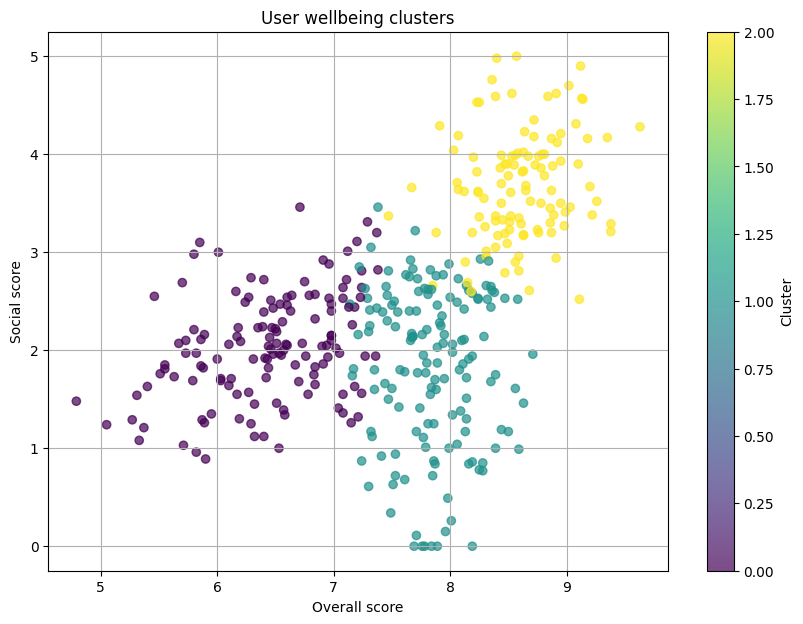

In [6]:
plt.figure(figsize=(10,7))

scatter = plt.scatter( 
    data["overall_score"],
    data["social_score"],
    c=data["cluster"],
    cmap="viridis", # väriteema
    alpha=0.7
) # alpha=0.7 tekee pisteistä hieman läpikuultavia, jotta päällekkäiset pisteet näkyvät paremmin

plt.colorbar(scatter, label="Cluster") # väripalkki, joka näyttää, mikä väri vastaa mitä klusteria

plt.xlabel("Overall score")
plt.ylabel("Social score")

plt.title("User wellbeing clusters")

plt.grid()
plt.show()

## Cluster interpretation

Klusteroinnin perusteella datasta löytyi kolme erilaista käyttäjäryhmää.

Visualisoinnissa näkyy, että käyttäjät eivät jakaudu täysin satunnaisesti, vaan muodostavat selkeitä hyvinvointiprofiileja.

Keltainen klusteri sisältää käyttäjiä, joilla sekä overall_score että social_score ovat korkeita. Tämä voi viitata käyttäjiin, joiden hyvinvointi ja sosiaalinen aktiivisuus ovat vakaalla tasolla.

Violetti klusteri sisältää käyttäjiä, joilla overall_score on matalampi ja myös sosiaalinen aktiivisuus on usein matalampaa. Tämä voi viitata käyttäjiin, jotka saattavat hyötyä lisätuesta tai aktiivisemmasta vuorovaikutuksesta.

Turkoosi klusteri sijoittuu näiden väliin. Ryhmässä näkyy käyttäjiä, joiden overall_score on melko hyvä, mutta social_score vaihtelee enemmän. Tämä voi viitata käyttäjiin, joiden hyvinvointi ei riipu pelkästään sosiaalisesta aktiivisuudesta.

Tulokset osoittavat, että käyttäjien hyvinvointiprofiilit voivat erota merkittävästi toisistaan.